In [1]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
def load_txt_dataset(directory):
    filepaths = []
    labels = []
    for label, class_name in enumerate(['healthy', 'sick']):
        class_dir = os.path.join(directory, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith('.txt'):
                filepaths.append(os.path.join(class_dir, fname))
                labels.append(label)
    return filepaths, labels


In [3]:
class TxtDataSequence(Sequence):
    def __init__(self, filepaths, labels, batch_size=32, target_size=(224,224), shuffle=True, augment=False):
        self.filepaths = filepaths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))
    
    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index+1) * self.batch_size, len(self.filepaths))
        batch_indices = self.indices[start:end]
        X, batch_labels = [], []
        for i in batch_indices:
            f = self.filepaths[i]
            with open(f, 'r') as file:
                first_line = file.readline().strip()
                delimiter = ';' if ';' in first_line else None
            img = np.loadtxt(f, delimiter=delimiter)
            if img.ndim == 2:
                img = np.expand_dims(img, axis=-1)
            if img.shape[-1] == 1:
                img = np.concatenate([img, img, img], axis=-1)
            img = cv2.resize(img, self.target_size)
            img = preprocess_input(img.astype('float32'))
            X.append(img)
            batch_labels.append(self.labels[i])
        return np.array(X), to_categorical(np.array(batch_labels), num_classes=2)
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [4]:
# Load dataset
dataset_dir = os.path.join('datasets', 'segmented2(txt)')
filepaths, labels = load_txt_dataset(dataset_dir)
train_filepaths, test_filepaths, train_labels, test_labels = train_test_split(
    filepaths, labels, test_size=0.3, random_state=42, stratify=labels
)
train_sequence = TxtDataSequence(train_filepaths, train_labels, batch_size=32, shuffle=True, augment=True)
test_sequence = TxtDataSequence(test_filepaths, test_labels, batch_size=32, shuffle=False, augment=False)


In [5]:
# Build model
input_shape = (224, 224, 3)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
for layer in base_model.layers:
    layer.trainable = False
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [6]:
# Define dynamic stopping callback
class DynamicStop(tf.keras.callbacks.Callback):
    def __init__(self, patience=5):
        super().__init__()
        self.patience = patience
        self.best_acc = 0
        self.wait = 0
    def on_epoch_end(self, epoch, logs=None):
        current_acc = logs.get('val_accuracy')
        if current_acc > self.best_acc:
            self.best_acc = current_acc
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"Stopping training at epoch {epoch+1}")
                self.model.stop_training = True


In [7]:
# Train Model
history = model.fit(
    train_sequence,
    epochs=50,  # Max possible epochs
    validation_data=test_sequence,
    callbacks=[DynamicStop(patience=5)],
    verbose=1
)


c:\Users\2004a\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6073 - loss: 1.0388 - val_accuracy: 0.6500 - val_loss: 0.5346
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6456 - loss: 0.7880 - val_accuracy: 0.7750 - val_loss: 0.4145
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7485 - loss: 0.5241 - val_accuracy: 0.8167 - val_loss: 0.3989
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7018 - loss: 0.6365 - val_accuracy: 0.8000 - val_loss: 0.4417
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7494 - loss: 0.5296 - val_accuracy: 0.8000 - val_loss: 0.4225
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7528 - loss: 0.4992 - val_accuracy: 0.8333 - val_loss: 0.4218
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7392 - loss: 0.4794 - val_accuracy: 0.8667 - val_loss: 0.3974
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7795 - loss: 0.4443 - val_accuracy: 0.8583 - val_loss: 0.4000
Epoch 9/

In [8]:
# Fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_finetune = model.fit(
    train_sequence,
    epochs=20,
    validation_data=test_sequence,
    callbacks=[DynamicStop(patience=3)],
    verbose=1
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8113 - loss: 0.3907 - val_accuracy: 0.8833 - val_loss: 0.3230
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8374 - loss: 0.2975 - val_accuracy: 0.8833 - val_loss: 0.3131
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9200 - loss: 0.2261 - val_accuracy: 0.8833 - val_loss: 0.3045
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9094 - loss: 0.2170 - val_accuracy: 0.8917 - val_loss: 0.2971
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9626 - loss: 0.1406 - val_accuracy: 0.8833 - val_loss: 0.2904
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9450 - loss: 0.1414 - val_accuracy: 0.8833 - val_loss: 0.2847
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9512 - loss: 0.1481 - val_accuracy: 0.9083 - val_loss: 0.2799
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9511 - loss: 0.1418 - val_accuracy: 0.9167 - val_loss: 0.2732
Epoch 9/

In [9]:
# Evaluate Model
eval_loss, eval_accuracy = model.evaluate(test_sequence, verbose=1)
print(f"Test Loss: {eval_loss:.4f}")
print(f"Test Accuracy: {eval_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 975ms/step - accuracy: 0.9135 - loss: 0.2499
Test Loss: 0.2589
Test Accuracy: 0.9167


In [11]:
predictions = []
true_labels_arr = []

# Iterate over the test sequence batches to collect predictions
for X_batch, y_batch in test_sequence:
    # Skip empty batches if any
    if X_batch.size == 0:
        break
    preds = model.predict(X_batch)
    predictions.extend(np.argmax(preds, axis=1))
    true_labels_arr.extend(np.argmax(y_batch, axis=1))

if len(true_labels_arr) == 0:
    raise ValueError("No test samples were processed. Check your data generator.")

# Trim predictions and labels to the exact number of test samples
predictions = np.array(predictions)[:len(test_filepaths)]
true_labels_arr = np.array(true_labels_arr)[:len(test_filepaths)]

# Compute confusion matrix
cm = confusion_matrix(true_labels_arr, predictions)
print("Confusion Matrix:\n", cm)

# Compute sensitivity and specificity if confusion matrix is 2x2
if cm.size == 4:
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"Sensitivity (TPR): {sensitivity:.4f}")
    print(f"Specificity (TNR): {specificity:.4f}")
else:
    print("Confusion matrix dimensions unexpected for binary classification.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 939ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
Confusion Matrix:
 [[56  4]
 [ 6 54]]
Sensitivity (TPR): 0.9000
Specificity (TNR): 0.9333


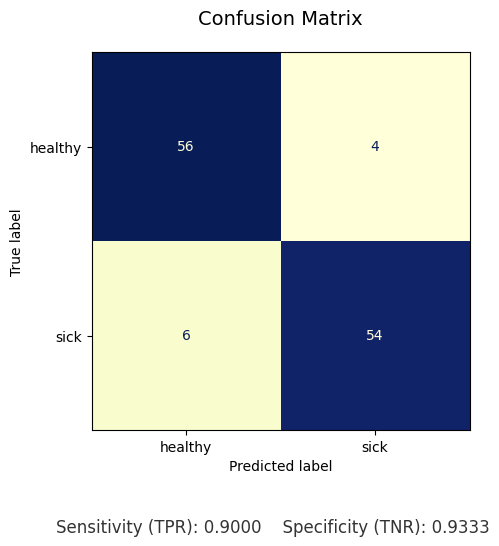

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Updated confusion matrix
cm = np.array([[56, 4],
               [ 6, 54]])

# Compute sensitivity & specificity
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

# Labels
labels = ['healthy', 'sick']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Plot with light colors and spacing
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='YlGnBu', colorbar=False)
ax.set_title('Confusion Matrix', pad=20, fontsize=14)

# Add spacing below the matrix
plt.subplots_adjust(bottom=0.25)

# Add sensitivity and specificity text below
plt.figtext(0.5, 0.08,
            f"Sensitivity (TPR): {sensitivity:.4f}    Specificity (TNR): {specificity:.4f}",
            ha='center', fontsize=12, color='#333333')

plt.show()


In [16]:
# Ensure all_sequence is defined
batch_size = 32
all_sequence = TxtDataSequence(filepaths, labels, batch_size=batch_size, target_size=(224,224), shuffle=False, augment=False)

# Generate predictions
predictions = model.predict(all_sequence, verbose=1)
predicted_labels = np.argmax(predictions, axis=1)

df_results = pd.DataFrame({
    'Filename': filepaths,
    'Actual': labels,
    'Predicted': predicted_labels
})

label_mapping = {0: 'healthy', 1: 'sick'}
df_results['Actual_Class'] = df_results['Actual'].map(label_mapping)
df_results['Predicted_Class'] = df_results['Predicted'].map(label_mapping)

# Save predictions to a space-separated text file
with open("predictions2.txt", "w") as f:
    for i in range(len(df_results)):
        f.write(f"{df_results.iloc[i]['Filename']} {df_results.iloc[i]['Actual']} {df_results.iloc[i]['Predicted']} {df_results.iloc[i]['Actual_Class']} {df_results.iloc[i]['Predicted_Class']}\n")

print("Predictions saved to predictions2.txt")

c:\Users\2004a\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
Predictions saved to predictions2.txt
